## Tugas 9 - Predicting Power Consumption using Linear Regression - Supervised Learning

> Download dataset (train_energy_data.csv dan test_energy_data.csv) disini : https://www.kaggle.com/datasets/govindaramsriram/energy-consumption-dataset-linear-regression?select=test_energy_data.csv

> Dataset merupakan data konsumsi daya berdasarkan banyak variabel lainnya.

> Dataset udah di-split menjadi: ``` train_energy_data.csv ``` dan ``` test_energy_data.csv ```

> Isi insight menggunakan bahasa sendiri dan bukan AI - generated.

> Deadline : 23.59 WIB - Senin, 27 April 2026.


---

Nama lengkap : Nicholas Kisu Candra

Asal universitas : Universitas Internasional Batam

---

### 0. Import Module yang diperlukan

> Import module yang diperlukan untuk mendukung seluruh kegiatan

In [1]:
# TODO : Import module yang diperlukan, misal: pandas, numpy, matplotlib, seaborn dan scikit-learn

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Optional: display settings
pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')

### 1. Problem Identification

> Jelaskan permasalahan yang ingin diselesaikan dari dataset ini. Contoh: "Bagaimana memprediksi konsumsi energi bangunan berdasarkan karakteristik bangunan dan lingkungan sekitar."

Dataset ini digunakan untuk memprediksi seberapa besar penggunaan listrik (dalam kWh) disebuah bangunan berdasarkan:
1. jenis bangunan (residential, indsutrial etc)
2. square footage (seberapa luas bangunan tsb)
3. number of occupants (berapa banyak orang yang ada dibangunan tsb)
4. appliances used (berapa banyak perabot yang menggunakan listrik dibangunan tsb)
5. average temperature (celcius, seberapa dingin/panas suhu ruangan bangunan tsb)
6. day of week (diantara weekday atau weekend)
7. energy consumption (dalam satuan kWh, berapa banyak yang dikonsumsi)

Permasalahan yang ingin diselesaikan adalah bagaimana memperkirakan jumlah konsumsi listrik suatu bangunan berdasarkan kombinasi faktor fisik dan operasional. Faktor fisik seperti luas bangunan dan jenis bangunan mempengaruhi kebutuhan energi dasar, sementara faktor operasional seperti jumlah penghuni dan jumlah perangkat listrik mempengaruhi seberapa intens energi digunakan. Selain itu, kondisi lingkungan seperti suhu rata-rata serta pola waktu (weekday atau weekend) juga dapat menyebabkan variasi konsumsi energi. Dengan memodelkan hubungan antar variabel tersebut, diharapkan dapat diprediksi konsumsi energi secara lebih akurat untuk kondisi bangunan tertentu.

### 2. Data Collection

> Di sini silakan muat data dan menuliskan deskripsi awal.

In [2]:
# TODO: Load dataset dari file CSV yang sudah diunduh
df_train = pd.read_csv('train_energy_data.csv')
df_test = pd.read_csv('test_energy_data.csv')

# Load dataset
df_train = pd.read_csv('train_energy_data.csv')
df_test = pd.read_csv('test_energy_data.csv')

# =========================
# Preview data
# =========================
print("=== TRAIN HEAD ===")
display(df_train.head())

print("\n=== TEST HEAD ===")
display(df_test.head())

# =========================
# Data info (structure)
# =========================
print("\n=== TRAIN INFO ===")
df_train.info()

print("\n=== TEST INFO ===")
df_test.info()

# =========================
# Descriptive statistics
# =========================
print("\n=== TRAIN DESCRIBE ===")
display(df_train.describe())

print("\n=== TEST DESCRIBE ===")
display(df_test.describe())

# =========================
# Additional statistics
# =========================
print("\n=== STATISTIK TAMBAHAN (TRAIN) ===")

numeric_cols = df_train.select_dtypes(include=np.number).columns

stats_df = pd.DataFrame({
    'mean': df_train[numeric_cols].mean(),
    'median': df_train[numeric_cols].median(),
    'mode': df_train[numeric_cols].mode().iloc[0],
    'variance': df_train[numeric_cols].var(),
    'std_dev': df_train[numeric_cols].std()
})

display(stats_df)

print("\n=== Unique Building Type ===")
print(df_train['Building Type'].unique())

=== TRAIN HEAD ===


,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17



=== TEST HEAD ===


,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,24563,15,4,28.52,Weekday,2865.57
1,Commercial,27583,56,23,23.07,Weekend,4283.80
2,Commercial,45313,4,44,33.56,Weekday,5067.83
3,Residential,41625,84,17,27.39,Weekend,4624.30
4,Residential,36720,58,47,17.08,Weekday,4820.59



=== TRAIN INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1000 non-null   str    
 1   Square Footage       1000 non-null   int64  
 2   Number of Occupants  1000 non-null   int64  
 3   Appliances Used      1000 non-null   int64  
 4   Average Temperature  1000 non-null   float64
 5   Day of Week          1000 non-null   str    
 6   Energy Consumption   1000 non-null   float64
dtypes: float64(2), int64(3), str(2)
memory usage: 54.8 KB

=== TEST INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        100 non-null    str    
 1   Square Footage       100 non-null    int64  
 2   Number of Occupants  100 non-null    int64  
 3   Appliances 

...


=== TEST DESCRIBE ===


,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
count,100.000000,100.000000,100.000000,100.000000,100.00000
mean,25881.920000,47.230000,26.970000,22.043300,4187.57830
std,13711.075264,29.905526,14.237846,6.957951,832.55985
min,1161.000000,2.000000,1.000000,10.400000,2351.97000
25%,14161.000000,21.000000,16.750000,15.682500,3621.92500
50%,27582.500000,47.000000,27.500000,21.970000,4249.39000
75%,38109.500000,73.000000,39.250000,27.492500,4797.17500
max,49354.000000,99.000000,49.000000,34.710000,6042.56000



=== STATISTIK TAMBAHAN (TRAIN) ===


,mean,median,mode,variance,std_dev
Square Footage,25462.38800,25477.000,11289.00,2.043343e+08,14294.554000
Number of Occupants,48.37200,47.000,21.00,8.445982e+02,29.061972
Appliances Used,25.60600,26.000,45.00,1.989557e+02,14.105166
Average Temperature,22.61139,22.815,16.24,5.097878e+01,7.139943
Energy Consumption,4166.25257,4175.730,1683.95,8.710733e+05,933.313064



=== Unique Building Type ===
<StringArray>
['Residential', 'Commercial', 'Industrial']
Length: 3, dtype: str


Berdasarkan hasil eksplorasi awal, seluruh variabel numerik memiliki distribusi yang relatif seimbang karena nilai mean dan median yang tidak berbeda jauh. Hal ini menunjukkan bahwa data tidak terlalu condong ke satu sisi (tidak skewed). 

Selain itu, tidak ditemukan missing values pada dataset sehingga data dapat langsung digunakan untuk proses modeling tanpa tahap pembersihan tambahan. 

Variabel seperti luas bangunan, jumlah penghuni, dan jumlah perangkat listrik memiliki rentang nilai yang cukup besar dan secara logika berpotensi memiliki pengaruh terhadap konsumsi energi. Sementara itu, variabel kategorikal seperti jenis bangunan dan hari dalam minggu perlu dikonversi terlebih dahulu sebelum digunakan dalam model.

### 3. Data Preprocessing

> Tahapan membersihkan data dan menangani data yang hilang atau rusak. Gunakan metode yang diperlukan.

In [3]:
# =========================
# 1. Encoding categorical features
# =========================
df_train_encoded = pd.get_dummies(df_train, columns=['Building Type', 'Day of Week'], drop_first=True)
df_test_encoded = pd.get_dummies(df_test, columns=['Building Type', 'Day of Week'], drop_first=True)

# Align kolom train & test (biar sama persis)
df_train_encoded, df_test_encoded = df_train_encoded.align(df_test_encoded, join='left', axis=1, fill_value=0)

# =========================
# 2. Pisahkan fitur dan target
# =========================
X_train = df_train_encoded.drop('Energy Consumption', axis=1)
y_train = df_train_encoded['Energy Consumption']

X_test = df_test_encoded.drop('Energy Consumption', axis=1)
y_test = df_test_encoded['Energy Consumption']

# =========================
# 3. Scaling (Standardization)
# =========================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Pada tahap preprocessing, tidak ditemukan missing values sehingga tidak dilakukan penanganan data hilang. Selanjutnya, fitur kategorikal seperti Building Type dan Day of Week dikonversi menjadi bentuk numerik menggunakan one-hot encoding. Setelah itu, data dipisahkan menjadi fitur (X) dan target (y). Untuk meningkatkan stabilitas model, dilakukan normalisasi menggunakan standardization agar setiap fitur memiliki skala yang sebanding.

### 4. EDA dan Visualisasi Data

> Menjelajahi data secara mendalam untuk mencari pola dan hubungan antar variabel.

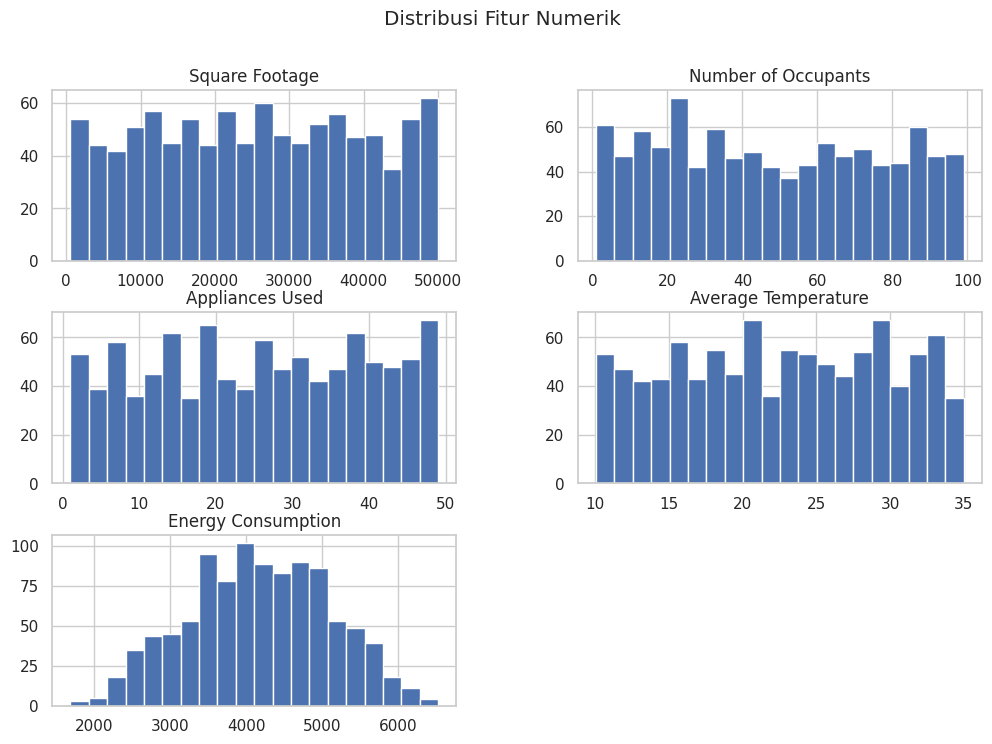

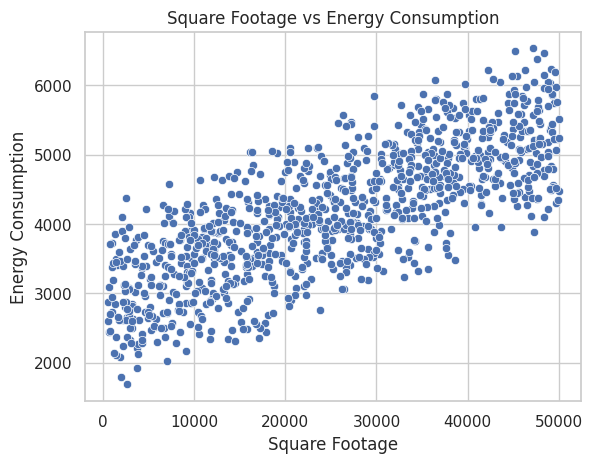

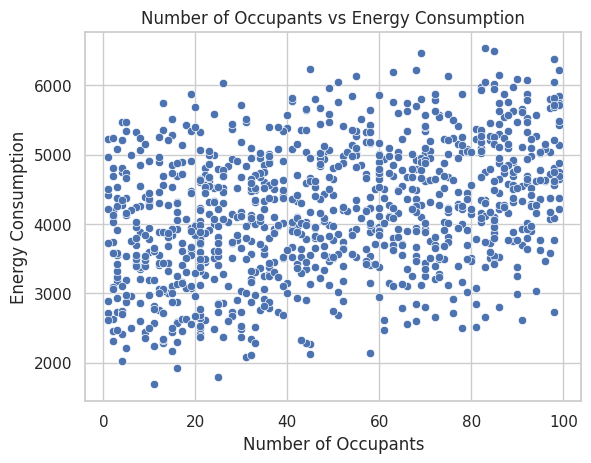

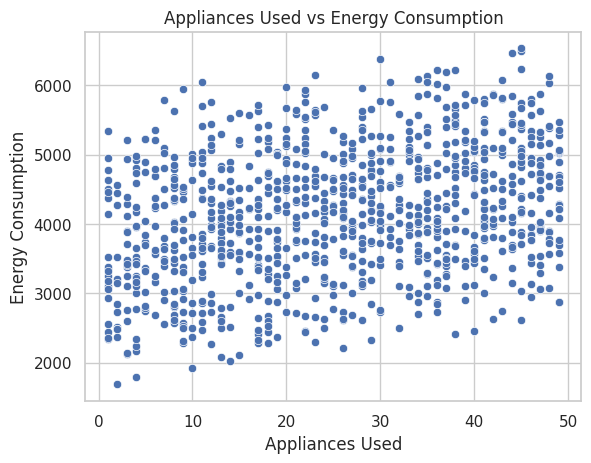

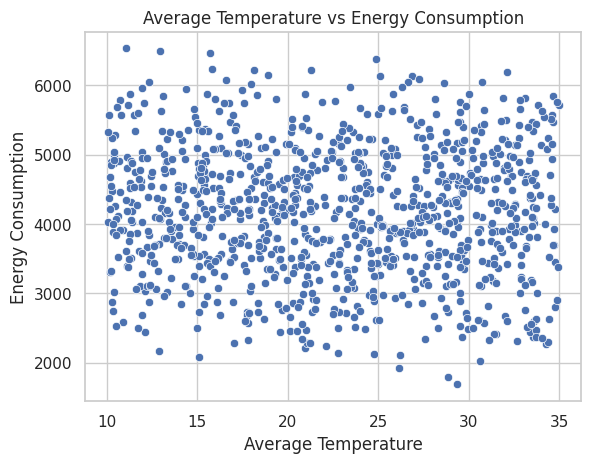

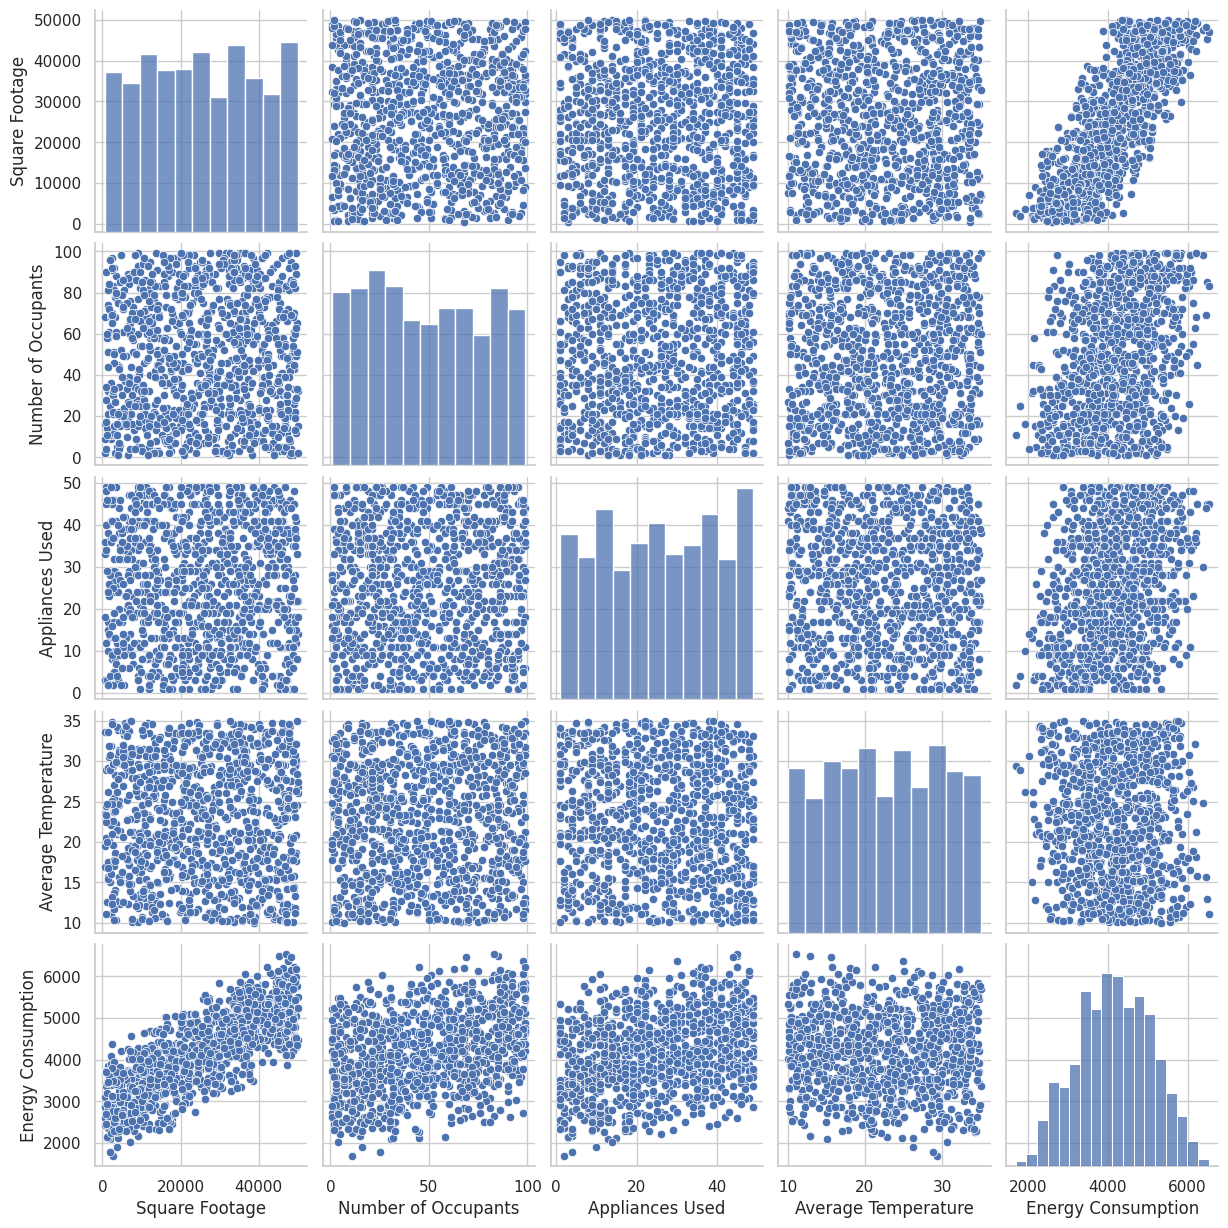

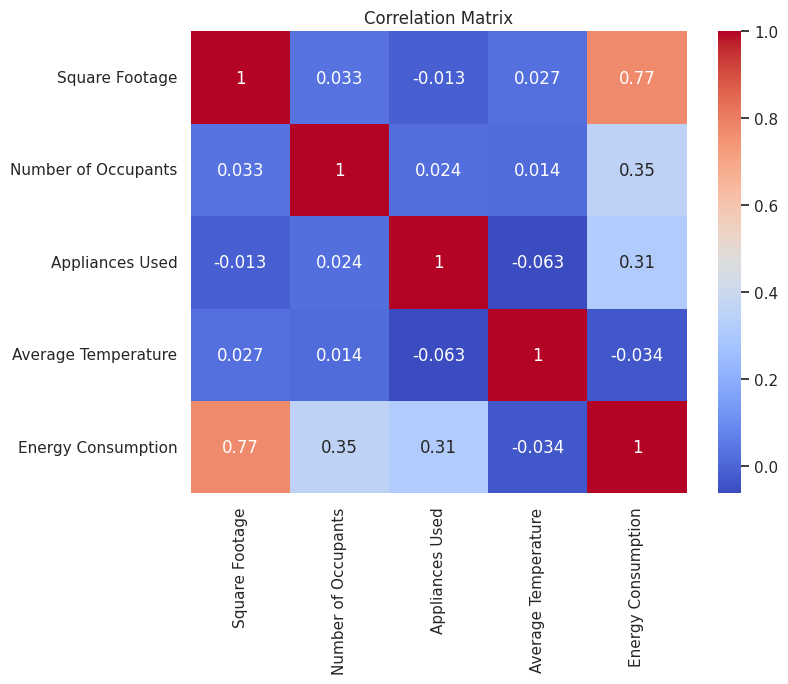

In [4]:
# =========================
# 1. Univariat (distribusi fitur numerik)
# =========================
numeric_cols = df_train.select_dtypes(include=np.number).columns

df_train[numeric_cols].hist(figsize=(12, 8), bins=20)
plt.suptitle("Distribusi Fitur Numerik")
plt.show()


# =========================
# 2. Bivariat (fitur vs target)
# =========================
target = 'Energy Consumption'

for col in numeric_cols:
    if col != target:
        plt.figure()
        sns.scatterplot(x=df_train[col], y=df_train[target])
        plt.title(f"{col} vs Energy Consumption")
        plt.show()


# =========================
# 3. Multivariat (pairplot)
# =========================
sns.pairplot(df_train[numeric_cols])
plt.show()


# =========================
# 4. Correlation heatmap
# =========================
corr_matrix = df_train[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Berdasarkan analisis bivariat dan heatmap korelasi, luas bangunan (Square Footage) memiliki hubungan paling kuat terhadap konsumsi energi dengan nilai korelasi yang tinggi. Hal ini menunjukkan bahwa semakin besar ukuran bangunan, maka konsumsi energi cenderung meningkat secara signifikan. Variabel jumlah penghuni dan jumlah perangkat listrik juga menunjukkan hubungan positif, namun tidak sekuat luas bangunan. Sementara itu, temperatur rata-rata tidak menunjukkan hubungan yang berarti terhadap konsumsi energi. Selain itu, korelasi antar fitur relatif rendah, yang menunjukkan bahwa masing-masing variabel memberikan informasi yang cukup independen terhadap model.

### 5. Pembangunan Model Regresi Linear dan Evaluasi Model

> Latih model menggunakan data yang sudah bersih dan lakukan evaluasi.

MAE: 0.01
R2 Score: 1.0000


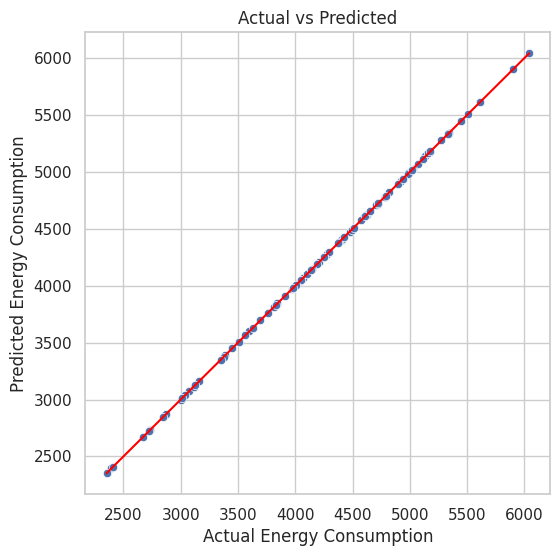

,Feature,Coefficient
0,Square Footage,714.370059
1,Number of Occupants,290.474461
2,Appliances Used,281.962524
4,Building Type_Industrial,232.653941
6,Day of Week_Weekend,-24.997935
3,Average Temperature,-35.682190
5,Building Type_Residential,-238.007968


In [5]:
# =========================
# 1. Build model
# =========================
model = LinearRegression()

# =========================
# 2. Train model
# =========================
model.fit(X_train_scaled, y_train)

# =========================
# 3. Prediksi
# =========================
y_pred = model.predict(X_test_scaled)

# =========================
# 4. Evaluasi
# =========================
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")

# =========================
# 5. Visualisasi
# =========================
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Energy Consumption")
plt.ylabel("Predicted Energy Consumption")
plt.title("Actual vs Predicted")

# garis ideal (y = x)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()

## Bonus: Confirm fitur paling berpengaruh

coeff_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

display(coeff_df)

Model Linear Regression menunjukkan performa yang sangat tinggi dengan nilai R² mendekati 1 dan MAE yang sangat kecil. Hal ini menunjukkan bahwa model mampu memprediksi konsumsi energi dengan tingkat akurasi yang sangat tinggi. Visualisasi antara nilai aktual dan prediksi juga menunjukkan bahwa hampir seluruh titik berada pada garis diagonal, yang menandakan kesesuaian yang sangat baik antara prediksi dan nilai sebenarnya.

Berdasarkan nilai koefisien, luas bangunan merupakan faktor yang paling berpengaruh terhadap konsumsi energi, diikuti oleh jumlah penghuni dan jumlah perangkat listrik. Sementara itu, variabel seperti temperatur dan hari dalam minggu memiliki pengaruh yang relatif kecil terhadap model.> Berikan insight soal kode diatas disini. (klik 2x lalu edit.)

Nilai performa yang sangat tinggi ini kemungkinan disebabkan oleh pola hubungan antar variabel yang sangat linear serta minimnya noise pada dataset.

### 6. Simpan model dan scaler

In [6]:
# TODO : Simpan model dan scaler (pakai joblib)

import joblib

# =========================
# Simpan model
# =========================
joblib.dump(model, 'linear_regression_model.pkl')

# =========================
# Simpan scaler
# =========================
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

### 7. Prediksi Data Baru dan Kesimpulan Akhir

> Coba prediksi data baru yang diinput manual oleh user.

In [13]:
import joblib

# =========================
# Load model & scaler
# =========================
model_loaded = joblib.load('linear_regression_model.pkl')
scaler_loaded = joblib.load('scaler.pkl')

# =========================
# Contoh data baru (HARUS sesuai format sebelum scaling)
# =========================
sample_data = pd.DataFrame({
    'Square Footage': [30000],
    'Number of Occupants': [50],
    'Appliances Used': [25],
    'Average Temperature': [25],
    'Building Type_Industrial': [0],
    'Building Type_Residential': [1],
    'Day of Week_Weekend': [0]
})

# =========================
# Scaling (pakai scaler yang sama!)
# =========================
sample_scaled = scaler_loaded.transform(sample_data)

# =========================
# Prediksi
# =========================
prediction = model_loaded.predict(sample_scaled)

print("Sample Input:")
display(sample_data)

print(f"Predicted Energy Consumption: {prediction[0]:.2f} kWh")

Sample Input:


,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Building Type_Industrial,Building Type_Residential,Day of Week_Weekend
0,30000,50,25,25,0,1,0


Predicted Energy Consumption: 3925.00 kWh


### 8. Kesimpulan Project:

> Berikan kesimpulan untuk project ini.

Model yang telah dilatih kemudian digunakan untuk melakukan prediksi terhadap data baru. Sebelum dilakukan prediksi, data terlebih dahulu diproses menggunakan scaler yang sama seperti pada data training untuk menjaga konsistensi skala. Hasil prediksi menunjukkan estimasi konsumsi energi berdasarkan kombinasi fitur yang diberikan.

Berdasarkan seluruh proses yang telah dilakukan, model Linear Regression mampu memprediksi konsumsi energi dengan tingkat akurasi yang sangat tinggi. Hal ini didukung oleh nilai evaluasi yang sangat baik serta hubungan linear yang kuat antara beberapa fitur dengan target, terutama luas bangunan. Fitur seperti jumlah penghuni dan jumlah perangkat listrik juga memberikan kontribusi terhadap prediksi, meskipun tidak sekuat luas bangunan. Sementara itu, beberapa variabel seperti temperatur dan hari dalam minggu memiliki pengaruh yang relatif kecil. Secara keseluruhan, model ini efektif digunakan untuk memprediksi konsumsi energi pada dataset yang memiliki pola hubungan linear seperti pada kasus ini.

>